# T2 · Two speeds and emissions

| | |
| --- | --- |
| **Paper** | Section 3, Eqs. (6)–(12); Table F1. |
| **Prerequisites** | T1; emission rate as a function of speed. |
| **Input units** | speed mph, length mi, time h, rate g/(veh h), emissions g. |
| **Expected outputs** | The time–distance split; Eq. (10) equal to the VMT/VHT form; three activity patterns with equal VMT and VHT but different emissions; the finite-link condition. |
| **Conditions** | One link; a common two-speed state (v_f, v_q); common zero-acceleration rates; delay within the finite-link allowance. |

Template: question, assumptions, derivation, worked example, figure, interpretation question.

## 1. Question
Vehicle-miles (VMT) and vehicle-hours (VHT) give how far and how long. Why are they not enough for emissions, and what extra state information does a bottleneck episode supply?

## 2. Assumptions
A traversal of length $L$ consists of a free-flow portion at $v_f$ and a queued portion at $v_q$; the rate $r(v)$ is a zero-acceleration rate (speed-only); transitions between the two speeds are instantaneous here (T4 relaxes this).

## 3. Derivation
Time and distance balances, Eqs. (6)–(7): $T_{\rm free}+T_{\rm queue}=T_f+w$ and $v_fT_{\rm free}+v_qT_{\rm queue}=L$, so $T_{\rm queue}=\frac{v_f}{v_f-v_q}w$. Then
$$e=e_0+\Gamma(v_q)\,w,\qquad e_0=r(v_f)\frac{L}{v_f},\qquad \Gamma(v_q)=\frac{v_fr(v_q)-v_qr(v_f)}{v_f-v_q}.$$
$\Gamma$ (g per vehicle-hour of delay) can be **negative**: it is the change in emission per mile between the two speeds divided by the change in travel time per mile, so $\Gamma<0$ when a mile in the queue emits less than a mile at $v_f$. With the archived CO$_2$ rates and $v_f=60$ mph this happens for $v_q$ above about 27 mph, and for most of the paper's admitted episodes (computed below).
Summed over a closed episode (T1): $E_P=D[e_0+\Gamma\bar w_P]$ (Eq. 10). With ${\rm VMT}=DL$, ${\rm VHT}=D(T_f+\bar w_P)$:
$$E_P=\frac{r(v_f)}{v_f}{\rm VMT}+\Gamma(v_q)\Big({\rm VHT}-\frac{\rm VMT}{v_f}\Big)\quad\text{(Eq. 12)}.$$
The free-flow portion must be nonnegative: $w\le L(1/v_q-1/v_f)$ (Eq. 9, the finite-link condition).

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'qvdfe').exists())
sys.path.insert(0, str(ROOT / 'src'))          # works with or without `pip install -e .`
import json
import numpy as np
import matplotlib.pyplot as plt
import qvdfe
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

def check(name, ok):
    print(('PASS  ' if ok else 'FAIL  ') + name)
    assert ok, name
RATES = qvdfe.load_rates()

## 4. Worked example
First the time–distance split and the two equivalent forms, then three activity patterns with identical VMT and VHT.

In [2]:
coef = RATES['CO2']['coef']
L, vf, vq, w = 1.0, 60.0, 20.0, 1 / 60          # mi, mph, mph, h (one minute of delay)
e = qvdfe.link_emission(L, vf, vq, w, coef)
print(f"T_free = {e['T_free']*60:.3f} min, T_queue = {e['T_queue']*60:.3f} min; e0 = {e['e0']:.2f} g, Gamma = {e['Gamma']:.2f} g/(veh h), e = {e['e']:.2f} g")
check('time balance', np.isclose(e['T_free'] + e['T_queue'], L / vf + w))
check('distance balance', np.isclose(vf * e['T_free'] + vq * e['T_queue'], L))
check('finite-link condition holds', bool(qvdfe.finite_link_ok(w, L, vf, vq)))
D = 3000
E10 = qvdfe.episode_total(D, w, L, vf, vq, coef)
E12 = qvdfe.vmt_vht_form(D * L, D * (L / vf + w), vf, vq, coef)
print(f'Eq. (10): {E10/1000:.4f} kg;  VMT/VHT form: {E12/1000:.4f} kg')
check('Eq. (10) equals the VMT/VHT form', np.isclose(E10, E12, rtol=1e-12))

T_free = 0.500 min, T_queue = 1.500 min; e0 = 277.80 g, Gamma = 1772.36 g/(veh h), e = 307.34 g
PASS  time balance
PASS  distance balance
PASS  finite-link condition holds
Eq. (10): 922.0182 kg;  VMT/VHT form: 922.0182 kg
PASS  Eq. (10) equals the VMT/VHT form


**Table F1 of the paper.** The same function at the detector-78 reference state of Appendix F. The paper rounds each column separately, so the displayed components need not add to the displayed total.

In [3]:
from qvdfe.data import load_reference_state
ref = load_reference_state()
shown = {'CO2': (294.6, 31.7, 326.2, 1), 'NOx': (0.4138, -0.0658, 0.3480, 4), 'CO': (1.9527, 0.6141, 2.5669, 4), 'HC': (0.0819, 0.0263, 0.1082, 4)}
for p, (s0, s1, st, d) in shown.items():
    ef = qvdfe.link_emission(ref['L_mi'], ref['vf_mph'], ref['vq_mph'], ref['mean_delay_h'], RATES[p]['coef'])
    inc = ef['Gamma'] * ref['mean_delay_h']
    print(f"{p:4s} e0 = {ef['e0']:.6g}, Gamma*wbar = {inc:.6g}, total = {ef['e']:.6g} g/veh  -> rounded {round(ef['e0'], d)}, {round(inc, d)}, {round(ef['e'], d)} (paper {s0}, {s1}, {st})")
    check(f'{p}: Table F1 reproduced', round(ef['e0'], d) == s0 and round(inc, d) == s1 and round(ef['e'], d) == st)
E = qvdfe.load_episodes(); A = E[E.matched_ladder_pass]
print(f"admitted episodes with Gamma_CO2 < 0: {int((A.Gamma_cubic_CO2 < 0).sum())} of {len(A)}; Gamma_NOx < 0: {int((A.Gamma_cubic_NOx < 0).sum())} of {len(A)}")

CO2  e0 = 294.56, Gamma*wbar = 31.6772, total = 326.237 g/veh  -> rounded 294.6, 31.7, 326.2 (paper 294.6, 31.7, 326.2)
PASS  CO2: Table F1 reproduced
NOx  e0 = 0.413787, Gamma*wbar = -0.0657737, total = 0.348014 g/veh  -> rounded 0.4138, -0.0658, 0.348 (paper 0.4138, -0.0658, 0.348)
PASS  NOx: Table F1 reproduced
CO   e0 = 1.95273, Gamma*wbar = 0.614131, total = 2.56686 g/veh  -> rounded 1.9527, 0.6141, 2.5669 (paper 1.9527, 0.6141, 2.5669)
PASS  CO: Table F1 reproduced
HC   e0 = 0.0819257, Gamma*wbar = 0.026314, total = 0.10824 g/veh  -> rounded 0.0819, 0.0263, 0.1082 (paper 0.0819, 0.0263, 0.1082)
PASS  HC: Table F1 reproduced
admitted episodes with Gamma_CO2 < 0: 75 of 137; Gamma_NOx < 0: 130 of 137


In [4]:
# Three traversals with the same distance (1 mi) and the same time (2 min): equal VMT and VHT per vehicle.
Ttot = L / vf + w
tt = np.linspace(0, Ttot, 20001)
patterns = {
    'steady at the average speed': np.full_like(tt, L / Ttot),
    'free flow then queue (two-speed)': np.where(tt < e['T_free'], vf, vq),
    'oscillating around the average': L / Ttot + 20 * np.sin(2 * np.pi * 4 * tt / Ttot),
}
rows = []
for name, v in patterns.items():
    dist, em = np.trapezoid(v, tt), np.trapezoid(qvdfe.cubic_rate(v, coef), tt)
    rows.append((name, dist, Ttot * 60, em))
    print(f'{name:34s} distance {dist:.4f} mi, time {Ttot*60:.2f} min, CO2 {em:7.2f} g  (speed range {v.min():.0f}-{v.max():.0f} mph)')
check('all three have the same distance', np.allclose([r[1] for r in rows], L, rtol=1e-4))
print('Speed-only rates are used for all three; the oscillating pattern would also carry acceleration effects that this rate omits.')

steady at the average speed        distance 1.0000 mi, time 2.00 min, CO2  264.16 g  (speed range 30-30 mph)
free flow then queue (two-speed)   distance 1.0000 mi, time 2.00 min, CO2  307.33 g  (speed range 20-60 mph)
oscillating around the average     distance 1.0000 mi, time 2.00 min, CO2  299.79 g  (speed range 10-50 mph)
PASS  all three have the same distance
Speed-only rates are used for all three; the oscillating pattern would also carry acceleration effects that this rate omits.


## 5. Figure

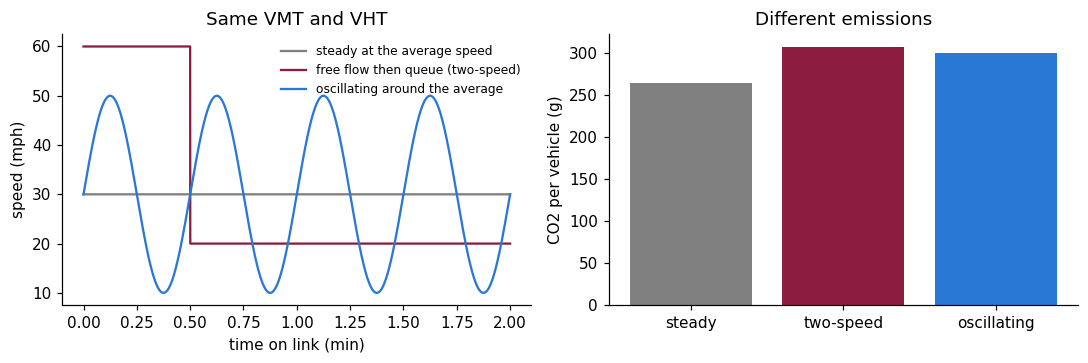

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for (name, v), c in zip(patterns.items(), ('grey', '#8C1D40', '#2a78d6')):
    ax[0].plot(tt * 60, v, color=c, label=name)
ax[0].set(xlabel='time on link (min)', ylabel='speed (mph)', title='Same VMT and VHT'); ax[0].legend(frameon=False, fontsize=8)
ax[1].bar(range(3), [r[3] for r in rows], color=['grey', '#8C1D40', '#2a78d6'])
ax[1].set_xticks(range(3), ['steady', 'two-speed', 'oscillating']); ax[1].set(ylabel='CO2 per vehicle (g)', title='Different emissions')
plt.tight_layout()

## 6. Interpretation question
The three traversals have the same VMT and VHT. Which property of $r(v)$ makes their emissions differ, and which quantity in Eq. (12) carries the bottleneck's state information that VMT and VHT lack?